In [4]:
import sys
print(sys.executable)
print(sys.version)

/opt/anaconda3/envs/py312_env/bin/python
3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]


# Notebook for Redoing EDA and such after 2.3 Feature Engineering

In [27]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
from src.features import feature_encoder, raw_data_loader
%matplotlib inline

In [6]:
df = raw_data_loader.load_and_clean_raw("..")

df_imputed = feature_encoder.encode_features(df.copy(), impute=True)
df = feature_encoder.encode_features(df.copy(), impute=False)


In [7]:
profile = ProfileReport(df, title="Sleep Apnea Dataset Profiling Report", explorative=True)

In [8]:
profile.to_file("../reports/3.0-profile-report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 149/149 [00:00<00:00, 335.28it/s]
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/ydata_profiling/model/pandas/duplicates_pandas.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index(name=duplicates_key)
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/ydata_profiling/model/pandas/duplicates_pandas.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index(name=duplicates_key)
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/ydata_profiling/model/pandas/duplicate

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

things of note/todo: 
1. check handling of -55 / missing values and what they represent in the data dictionary
2. better check for outliers 
3. the -55 placeholders and similar are usually rperesentative of "idk" so maybe try encoding them differently

also stuff from the end of 2.3 notebook
1. Feature selection before FA — use only the ~6 top SHAP factors' original variables as input to FA, rather than all features. Less noise going in
2. smoteenn or smotetomek?
3. lightgbm maybe 
4. stacking ensembles 
5. cross-validate shap values

In [23]:
from sklearn.ensemble import IsolationForest
import numpy as np
df_imputed = df_imputed.copy()
X = df_imputed.drop(columns=["ahi"])  # Assuming 'ahi' is the target variable

clf = IsolationForest(n_estimators=10, warm_start=True)
clf.fit(X)  # fit 10 trees
clf.set_params(n_estimators=20)  # add 10 more trees
clf.fit(X)  # fit the added trees

IsolationForest(n_estimators=20, warm_start=True)

In [24]:
# Calculate anomaly scores and classify anomalies
X = X.loc[X.index].copy()
X['anomaly_score'] = clf.decision_function(X)
X['anomaly'] = clf.predict(X.drop(columns=['anomaly_score']))
X['anomaly'].value_counts()

anomaly
 1    892
-1    795
Name: count, dtype: int64

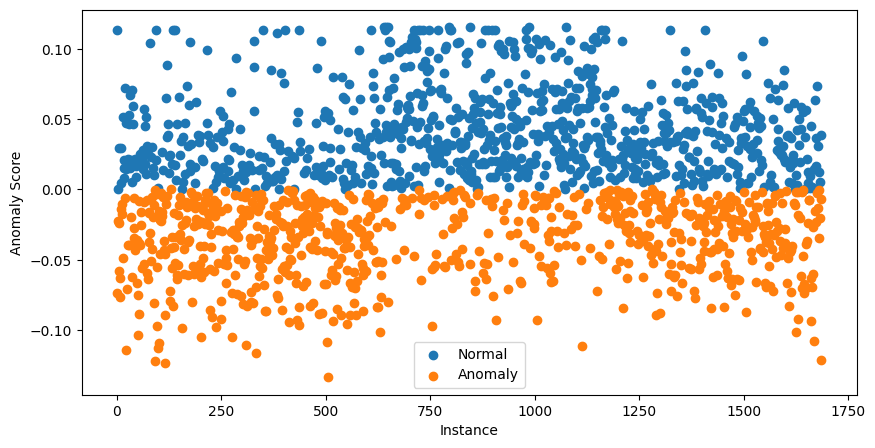

In [29]:
import matplotlib.pyplot as plt
# Visualization of the results
plt.figure(figsize=(10, 5))

# Plot normal instances
normal = X[X['anomaly'] == 1]
plt.scatter(normal.index, normal['anomaly_score'], label='Normal')
# Plot anomalies
anomalies = X[X['anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['anomaly_score'], label='Anomaly')
plt.xlabel("Instance")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

need to encode better probably gah
try multiple approaches prolly because ther er now way there r that many anomalies